## 1. Introduction
The goal of this task is to cluster synthetic protoplanetary disk images without supervision.
Since no labels are provided, this is treated as an unsupervised learning problem.

A key challenge in this dataset is avoiding clustering dominated by viewing angle (inclination)
rather than physically meaningful disk structures such as rings and gaps that may indicate
planet formation.

To address this, I implemented three approaches:

1. CNN-based feature extraction using a pretrained ResNet18.
2. Radial intensity profile clustering (physics-motivated).
3. A hybrid approach combining CNN and radial features.

The hybrid method produced the most interpretable clusters.



In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm import tqdm
import torch
import torch.nn.functional as F
import torchvision.models as models
import torch.nn as nn
from sklearn.cluster import KMeans
import umap
import torchvision.transforms as transforms
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [35]:
data_directory = "./images"

In [36]:
def load_img(data_directory):
    images = []
    filenames = []

    for file in tqdm(os.listdir(data_directory)):
        if file.endswith(".fits"):
            path = os.path.join(data_directory, file)

            with fits.open(path) as hdul:
                data = hdul[0].data

                image = data[0, 0, 0]

                images.append(image)
                filenames.append(file)

    return np.array(images), filenames

In [37]:
images, filenames = load_img(data_directory)
print("Shape: ", images.shape)

100%|██████████| 150/150 [00:00<00:00, 858.24it/s]


Shape:  (150, 600, 600)


In [38]:
# normalize

def normalize_img(images):
    normalized = []
    for img in images:
        img = img - np.min(img)
        img = img / (np.max(img) + 1e-8)
        normalized.append(img)
    return np.array(normalized)

images = normalize_img(images)
print("After normalization:", images.shape)

After normalization: (150, 600, 600)


In [39]:
images_tensor = torch.tensor(images).unsqueeze(1).float()

images_resized = F.interpolate(images_tensor, size=(224,224), mode='bilinear')

print(images_resized.shape)

torch.Size([150, 1, 224, 224])


In [40]:

imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

## 2. CNN-Based Feature Clustering

A pretrained ResNet18 model was used as a feature extractor.
Images were converted to 3-channel format to match the ImageNet-trained model.
The classification head was removed and 512-dimensional embeddings were extracted.
KMeans clustering was then applied to these embeddings.

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

resnet = models.resnet18(pretrained=True)

feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [42]:
# feature extraction

features = []

with torch.no_grad():
    for img in images_resized:


        img = img.repeat(3,1,1)


        img = img - img.min()
        img = img / (img.max() + 1e-8)


        img = imagenet_norm(img)

        img = img.unsqueeze(0).to(device)

        feat = feature_extractor(img)
        features.append(feat.cpu().numpy().flatten())

features = np.array(features)

print("Feature variance:", np.mean(np.var(features, axis=0)))

Feature variance: 5.3797905e-10


In [43]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(features)

print(np.unique(clusters))
print(np.bincount(clusters))

[0 1 2]
[142   7   1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


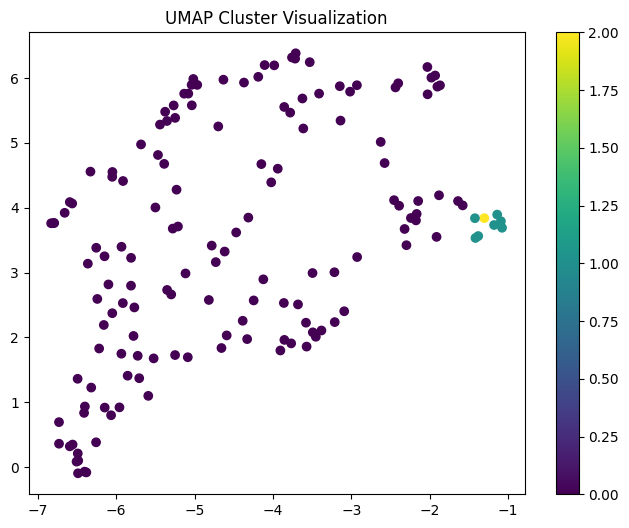

In [44]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=clusters,
    cmap='viridis'
)
plt.title("UMAP Cluster Visualization")
plt.colorbar()
plt.show()


### Observation

CNN-based clustering partially grouped disks by inclination.
Although structural variations were captured, one cluster appeared dominated by viewing angle.
This motivated the introduction of physics-informed radial features.

## 3. Radial Intensity Profile Clustering

To reduce orientation bias, radial intensity profiles were computed
by averaging pixel intensity in concentric annuli around the disk center.
This emphasizes radial gap structure while suppressing azimuthal asymmetry.

In [45]:

# radial compute

def radial_profile(image, center=None):
    y, x = np.indices(image.shape)

    if center is None:
        center = (image.shape[0] // 2, image.shape[1] // 2)

    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(np.int32)

    tbin = np.bincount(r.ravel(), image.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / (nr + 1e-8)

    return radialprofile

In [46]:
# profiles for disks

profiles = []

for img in images:
    prof = radial_profile(img)
    profiles.append(prof)

min_len = min(len(p) for p in profiles)
profiles = np.array([p[:min_len] for p in profiles])

print("Profiles shape:", profiles.shape)

Profiles shape: (150, 425)


In [47]:
# Normalize profile
profiles = profiles - profiles.min(axis=1, keepdims=True)
profiles = profiles / (profiles.max(axis=1, keepdims=True) + 1e-8)

In [48]:
k = 3
kmeans_radial = KMeans(n_clusters=k, random_state=42)
clusters_radial = kmeans_radial.fit_predict(profiles)

print(np.unique(clusters_radial))
print(np.bincount(clusters_radial))

[0 1 2]
[ 26  20 104]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


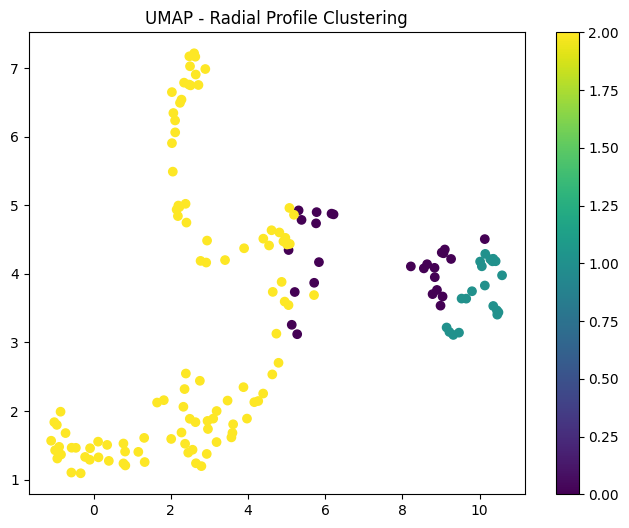

In [49]:
reducer = umap.UMAP(random_state=42)
embedding_radial = reducer.fit_transform(profiles)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding_radial[:,0],
    embedding_radial[:,1],
    c=clusters_radial,
    cmap='viridis'
)
plt.title("UMAP - Radial Profile Clustering")
plt.colorbar()
plt.show()

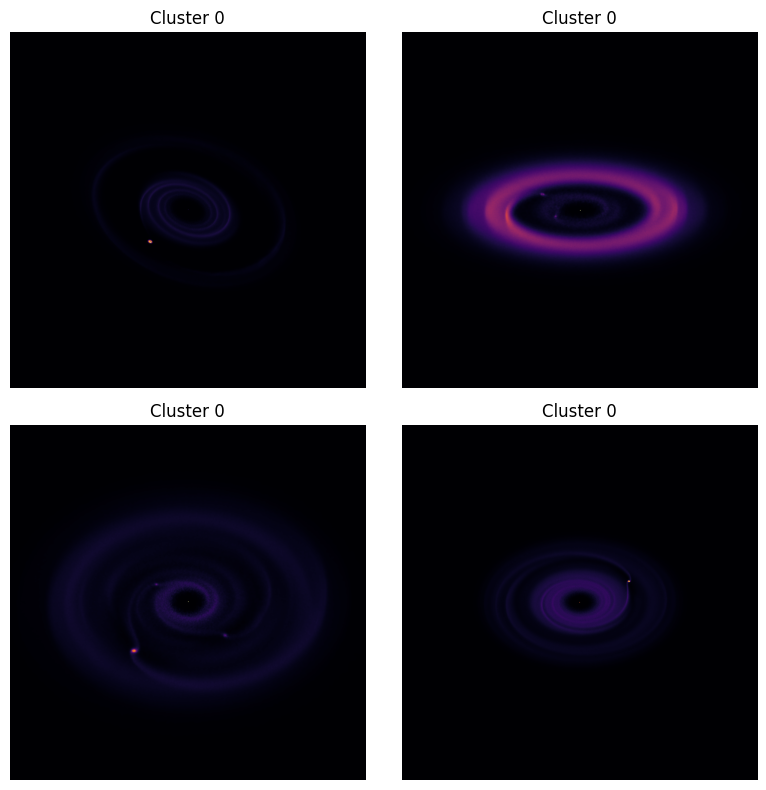

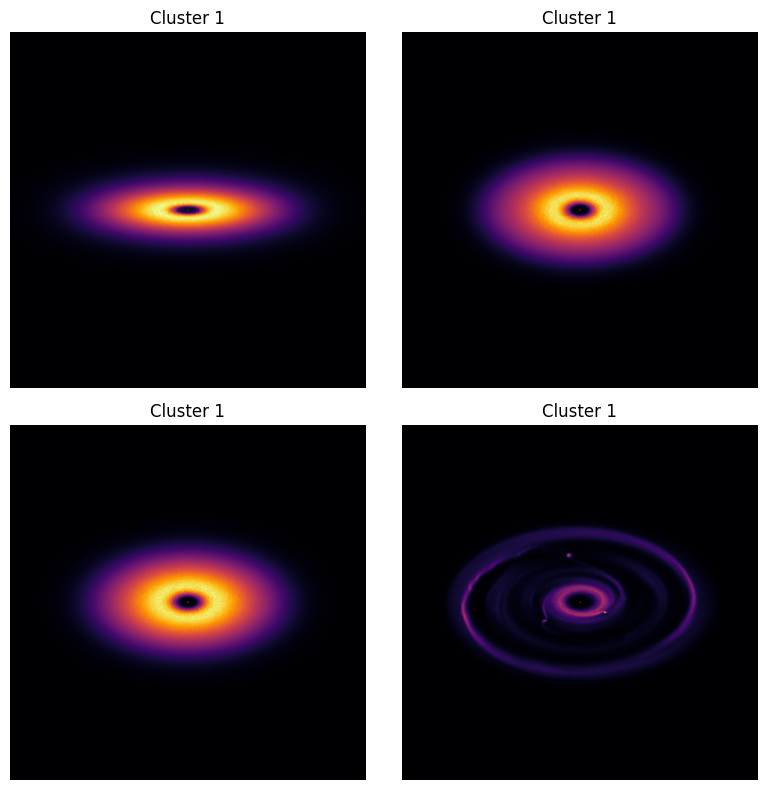

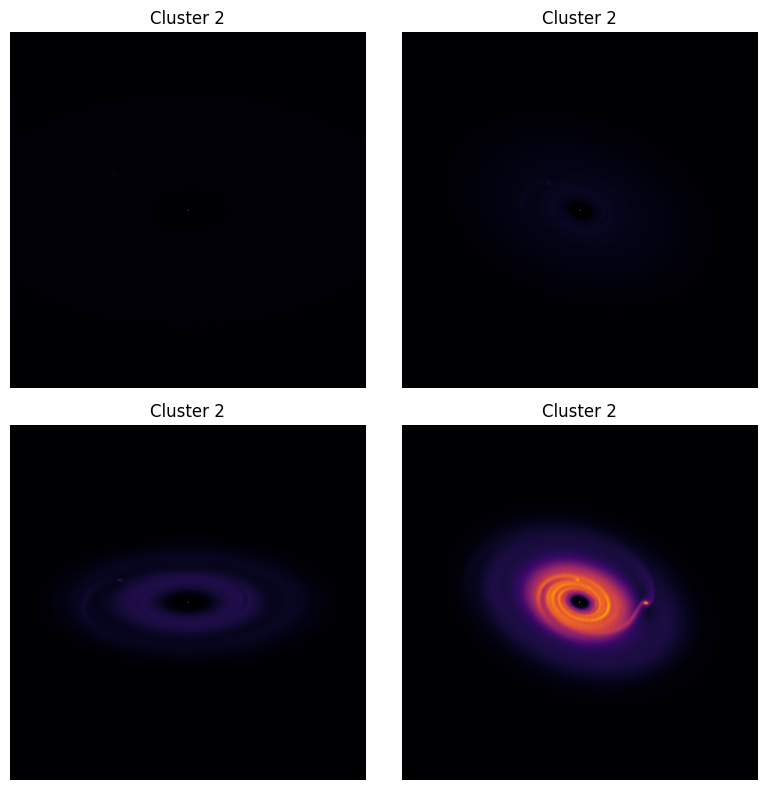

In [50]:
def cluster_radial(cluster_id, n=4):
    idx = np.where(clusters_radial == cluster_id)[0][:n]

    plt.figure(figsize=(8,8))
    for i, index in enumerate(idx):
        plt.subplot(2,2,i+1)
        plt.imshow(images[index], cmap='inferno')
        plt.title(f"Cluster {cluster_id}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

for c in range(k):
    cluster_radial(c)

### Observation

Radial clustering reduced inclination dominance and grouped disks
based on radial brightness structure.
However, subtle asymmetries were partially averaged out.

## 4. Hybrid CNN + Radial Feature Clustering

To combine texture-sensitive CNN embeddings with physically motivated
radial structure features, both feature types were standardized and concatenated.
Dimensionality reduction using PCA was applied before clustering.

In [51]:
scaler_cnn = StandardScaler()
features_scaled = scaler_cnn.fit_transform(features)

scaler_radial = StandardScaler()
profiles_scaled = scaler_radial.fit_transform(profiles)

In [52]:
combined_features = np.concatenate(
    [features_scaled, profiles_scaled],
    axis=1
)

print("Combined shape:", combined_features.shape)

Combined shape: (150, 937)


In [53]:
pca = PCA(n_components=50)
combined_reduced = pca.fit_transform(combined_features)

print("Reduced shape:", combined_reduced.shape)

Reduced shape: (150, 50)


In [54]:
k = 3
kmeans_combined = KMeans(n_clusters=k, random_state=42)
clusters_combined = kmeans_combined.fit_predict(combined_reduced)
score = silhouette_score(combined_reduced, clusters_combined)
print("Silhouette Score:", score)
print(np.unique(clusters_combined))
print(np.bincount(clusters_combined))

Silhouette Score: 0.4452754843548296
[0 1 2]
[ 26  16 108]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


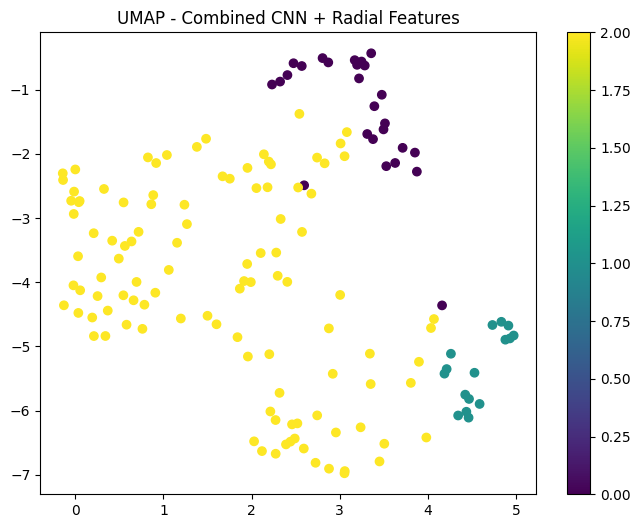

In [55]:
reducer = umap.UMAP(random_state=42)
embedding_combined = reducer.fit_transform(combined_reduced)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding_combined[:,0],
    embedding_combined[:,1],
    c=clusters_combined,
    cmap='viridis'
)
plt.title("UMAP - Combined CNN + Radial Features")
plt.colorbar()
plt.show()

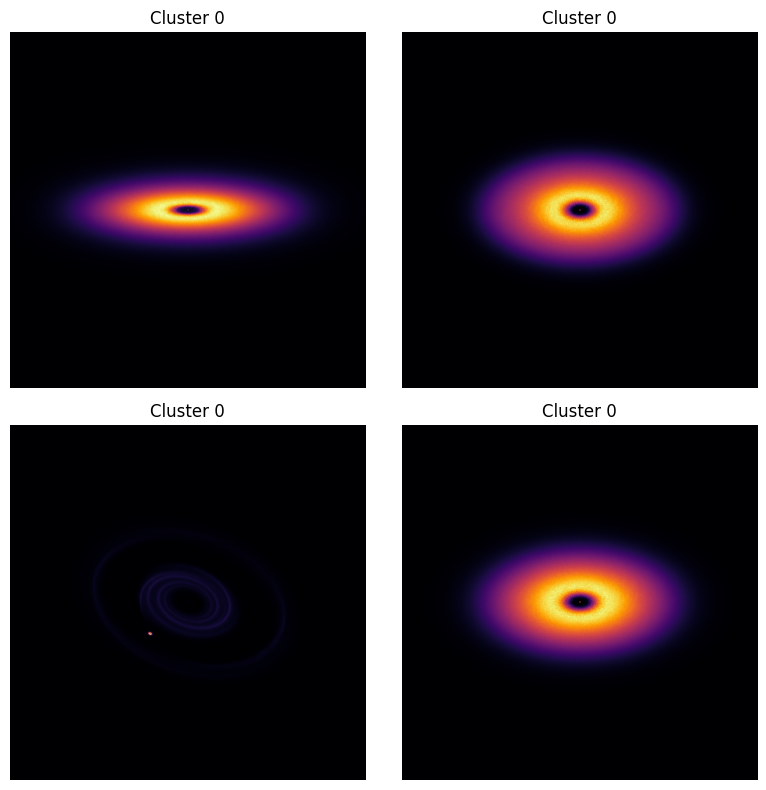

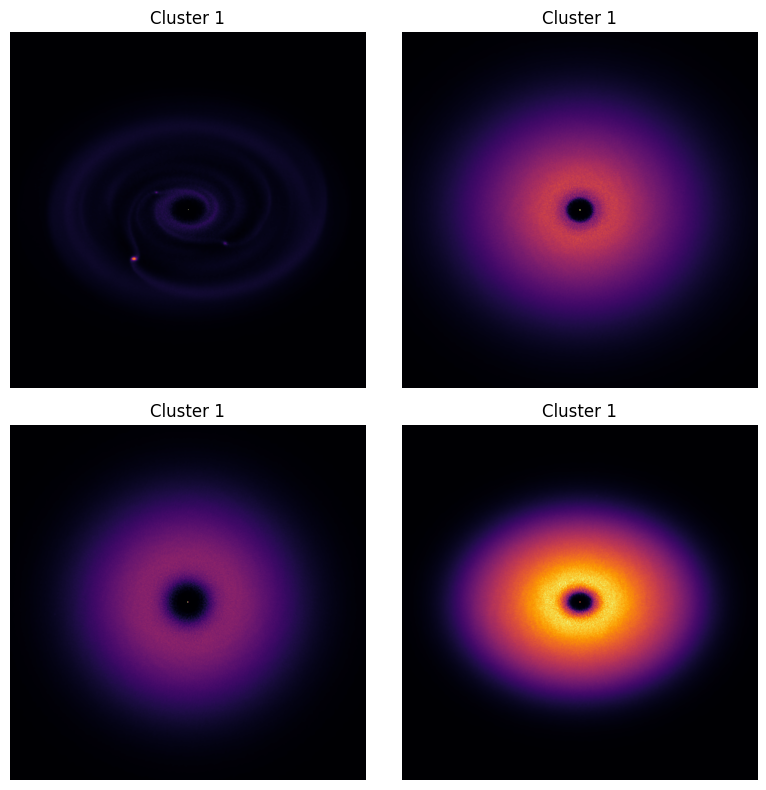

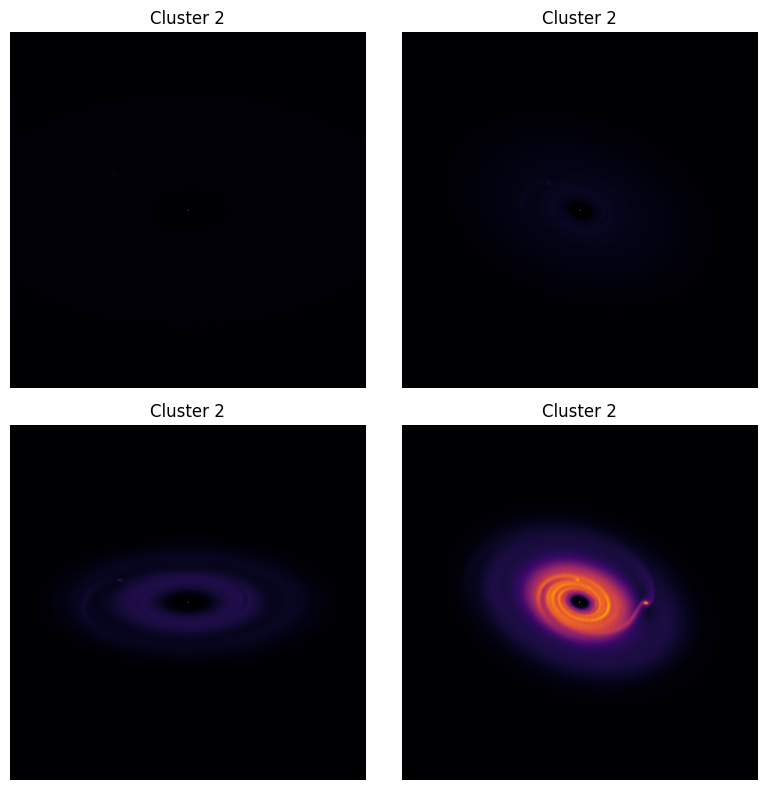

In [56]:
def cluster_combined(cluster_id, n=4):
    idx = np.where(clusters_combined == cluster_id)[0][:n]

    plt.figure(figsize=(8,8))
    for i, index in enumerate(idx):
        plt.subplot(2,2,i+1)
        plt.imshow(images[index], cmap='inferno')
        plt.title(f"Cluster {cluster_id}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

for c in range(k):
    cluster_combined(c)

### Final Results

Three major clusters emerged:

- Cluster 0: Smooth or mildly structured disks
- Cluster 1: Moderately structured disks
- Cluster 2: Highly structured multi-ring systems

The hybrid representation reduced orientation bias while preserving
morphological complexity, resulting in improved cluster separability.

## 5. Conclusion

The hybrid feature representation combining CNN embeddings and radial
intensity profiles produced the most interpretable clustering results.

This approach demonstrates the importance of integrating domain knowledge
with deep learning in scientific ML applications.

Future work could include inclination correction, density-based clustering,
or self-supervised representation learning.